In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv('StudentsPerformance.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


In [7]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [9]:
df.rename(columns = {
'race/ethnicity': 'race',
'parental level of education': 'parent_education',
'test preparation course': 'test_preparation_course',
'math score': 'math_score',
'reading score': 'reading_score',
'writing score': 'writing_score',
 } , inplace =True
)

In [19]:
df.columns

Index(['gender', 'race', 'parent_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'pass_math', 'pass_reading', 'pass_writing'],
      dtype='object')

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
reading_full = df [df['reading_score'] == 100]['reading_score'].count()
writing_full = df [df['writing_score'] == 100]['writing_score'].count()
math_full = df [df['math_score'] == 100]['math_score'].count()

print(f'Number of students with full marks in Reading: {reading_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Math: {math_full}')

Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14
Number of students with full marks in Math: 7


In [12]:
pass_grade =50
df['pass_math'] ='yes'
filt =(df['math_score'] <pass_grade)
df.loc[filt , 'pass_math'] ='no'
df[['math_score' , 'pass_math' ]].head()


df['pass_reading'] ='yes'
filt =(df['reading_score'] <pass_grade)
df.loc[filt , 'pass_reading'] ='no'
df[['reading_score' , 'pass_reading' ]].head()


df['pass_writing'] ='yes'
filt =(df['writing_score'] <pass_grade)
df.loc[filt , 'pass_writing'] ='no'
df[['writing_score' , 'pass_writing' ]].head()

df

,gender,race,parent_education,lunch,test_preparation_course,math_score,reading_score,writing_score,pass_math,pass_reading,pass_writing
0,female,group B,bachelor's degree,standard,none,72,72,74,yes,yes,yes
1,female,group C,some college,standard,completed,69,90,88,yes,yes,yes
2,female,group B,master's degree,standard,none,90,95,93,yes,yes,yes
3,male,group A,associate's degree,free/reduced,none,47,57,44,no,yes,no
4,male,group C,some college,standard,none,76,78,75,yes,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,yes,yes,yes
996,male,group C,high school,free/reduced,none,62,55,55,yes,yes,yes
997,female,group C,high school,free/reduced,completed,59,71,65,yes,yes,yes
998,female,group D,some college,standard,completed,68,78,77,yes,yes,yes


In [13]:
pass_math_count =df.groupby('pass_math')['pass_math'].count()
pass_math_count

,pass_math
pass_math,
no,135
yes,865


This cell creates one figure that contains three plots next to each other.

The figure has 1 row and 3 columns, so we can compare subjects easily.

Each plot shows the distribution of students’ scores.

The first plot shows Math scores.

The second plot shows Reading scores.

The third plot shows Writing scores.

ax[0], ax[1], and ax[2] are used to tell Python where each plot should be drawn.

The figure size is set to make the plots wide and easy to read.

plt.show() displays all plots on the screen.

Average score in Math: 66.089
Average score in Reading: 69.169
Average score in Writing: 68.054


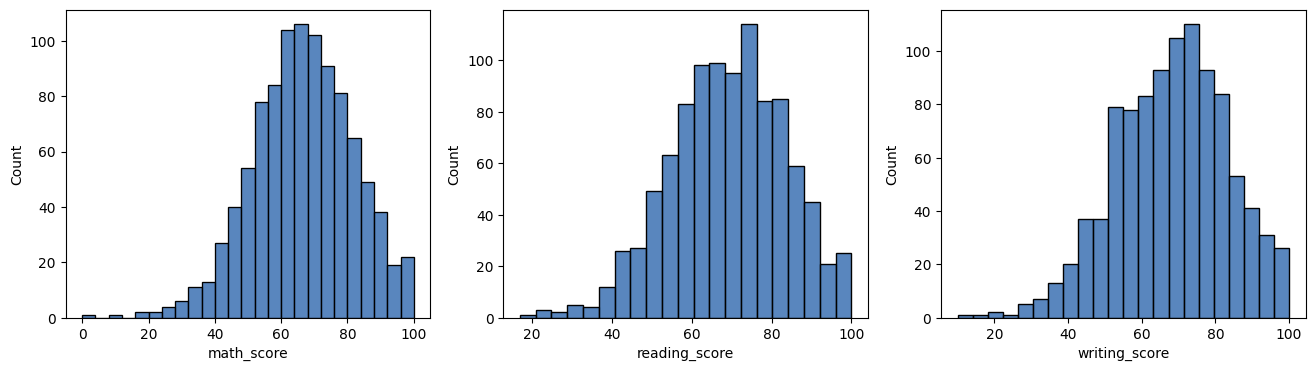

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=df, x='math_score', ax=ax[0], color="#225ea8")
sns.histplot(data=df, x='reading_score', ax=ax[1], color="#225ea8")
sns.histplot(data=df, x='writing_score', ax=ax[2], color="#225ea8")

math_mean = df['math_score'].mean()
reading_mean = df['reading_score'].mean()
writing_mean = df['writing_score'].mean()

print(f'Average score in Math: {math_mean}')
print(f'Average score in Reading: {reading_mean}')
print(f'Average score in Writing: {writing_mean}')

plt.show()


Count plots for pass and fail

What this cell does:

This cell shows how many students passed or failed each subject.

It creates three plots in one row.

The first plot shows pass/fail counts for Math.

The second plot shows pass/fail counts for Reading.

The third plot shows pass/fail counts for Writing.

Each plot uses a count plot to count how many students are in each category.

Using ax[0], ax[1], and ax[2] helps place each plot in the correct position.

This helps us compare pass rates between subjects visually.

pass_math
no     135
yes    865
Name: pass_math, dtype: int64
pass_math
no     135
yes    865
Name: pass_math, dtype: int64
pass_writing
no     114
yes    886
Name: pass_writing, dtype: int64


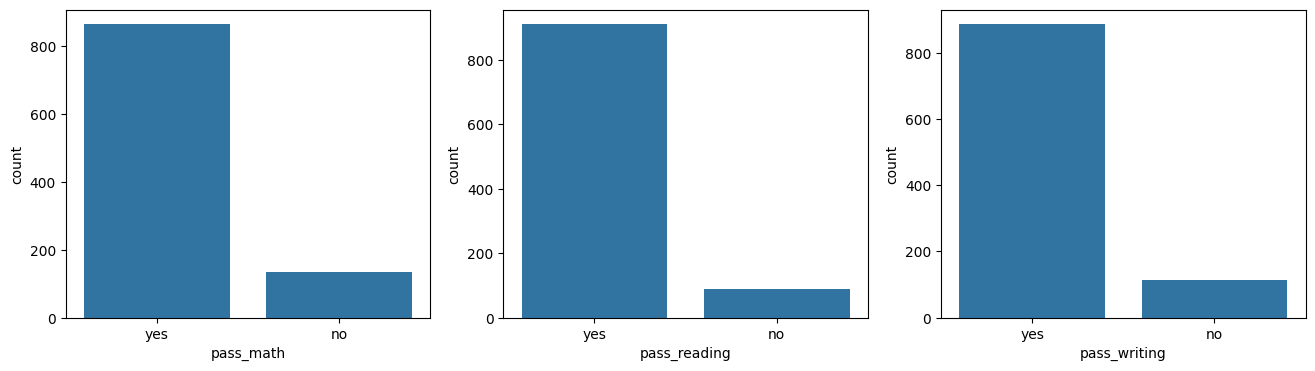

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x='pass_math', data=df, ax=ax[0])
sns.countplot(x='pass_reading', data=df, ax=ax[1])
sns.countplot(x='pass_writing', data=df, ax=ax[2])

pass_math_count = df.groupby('pass_math') ['pass_math'].count()
print(pass_math_count)
pass_math_count - df.groupby('pass_reading')['pass_reading'].count()
print(pass_math_count)
pass_math_count = df.groupby('pass_writing')['pass_writing'].count()
print(pass_math_count)
plt.show()


In [16]:
df['parent_education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

This cell uses pie charts to show student information as percentages.

The figure is made larger so all charts are easy to see.

The charts are arranged in 2 rows and 3 columns.

Each pie chart shows how the data is divided into groups.

The first chart shows Gender distribution.

The second chart shows Race / Ethnicity distribution.

The third chart shows Lunch type distribution.

The fourth chart shows Test preparation course status.

The fifth chart shows Parents’ education levels.

Percentages are displayed on each pie slice to make results clear.

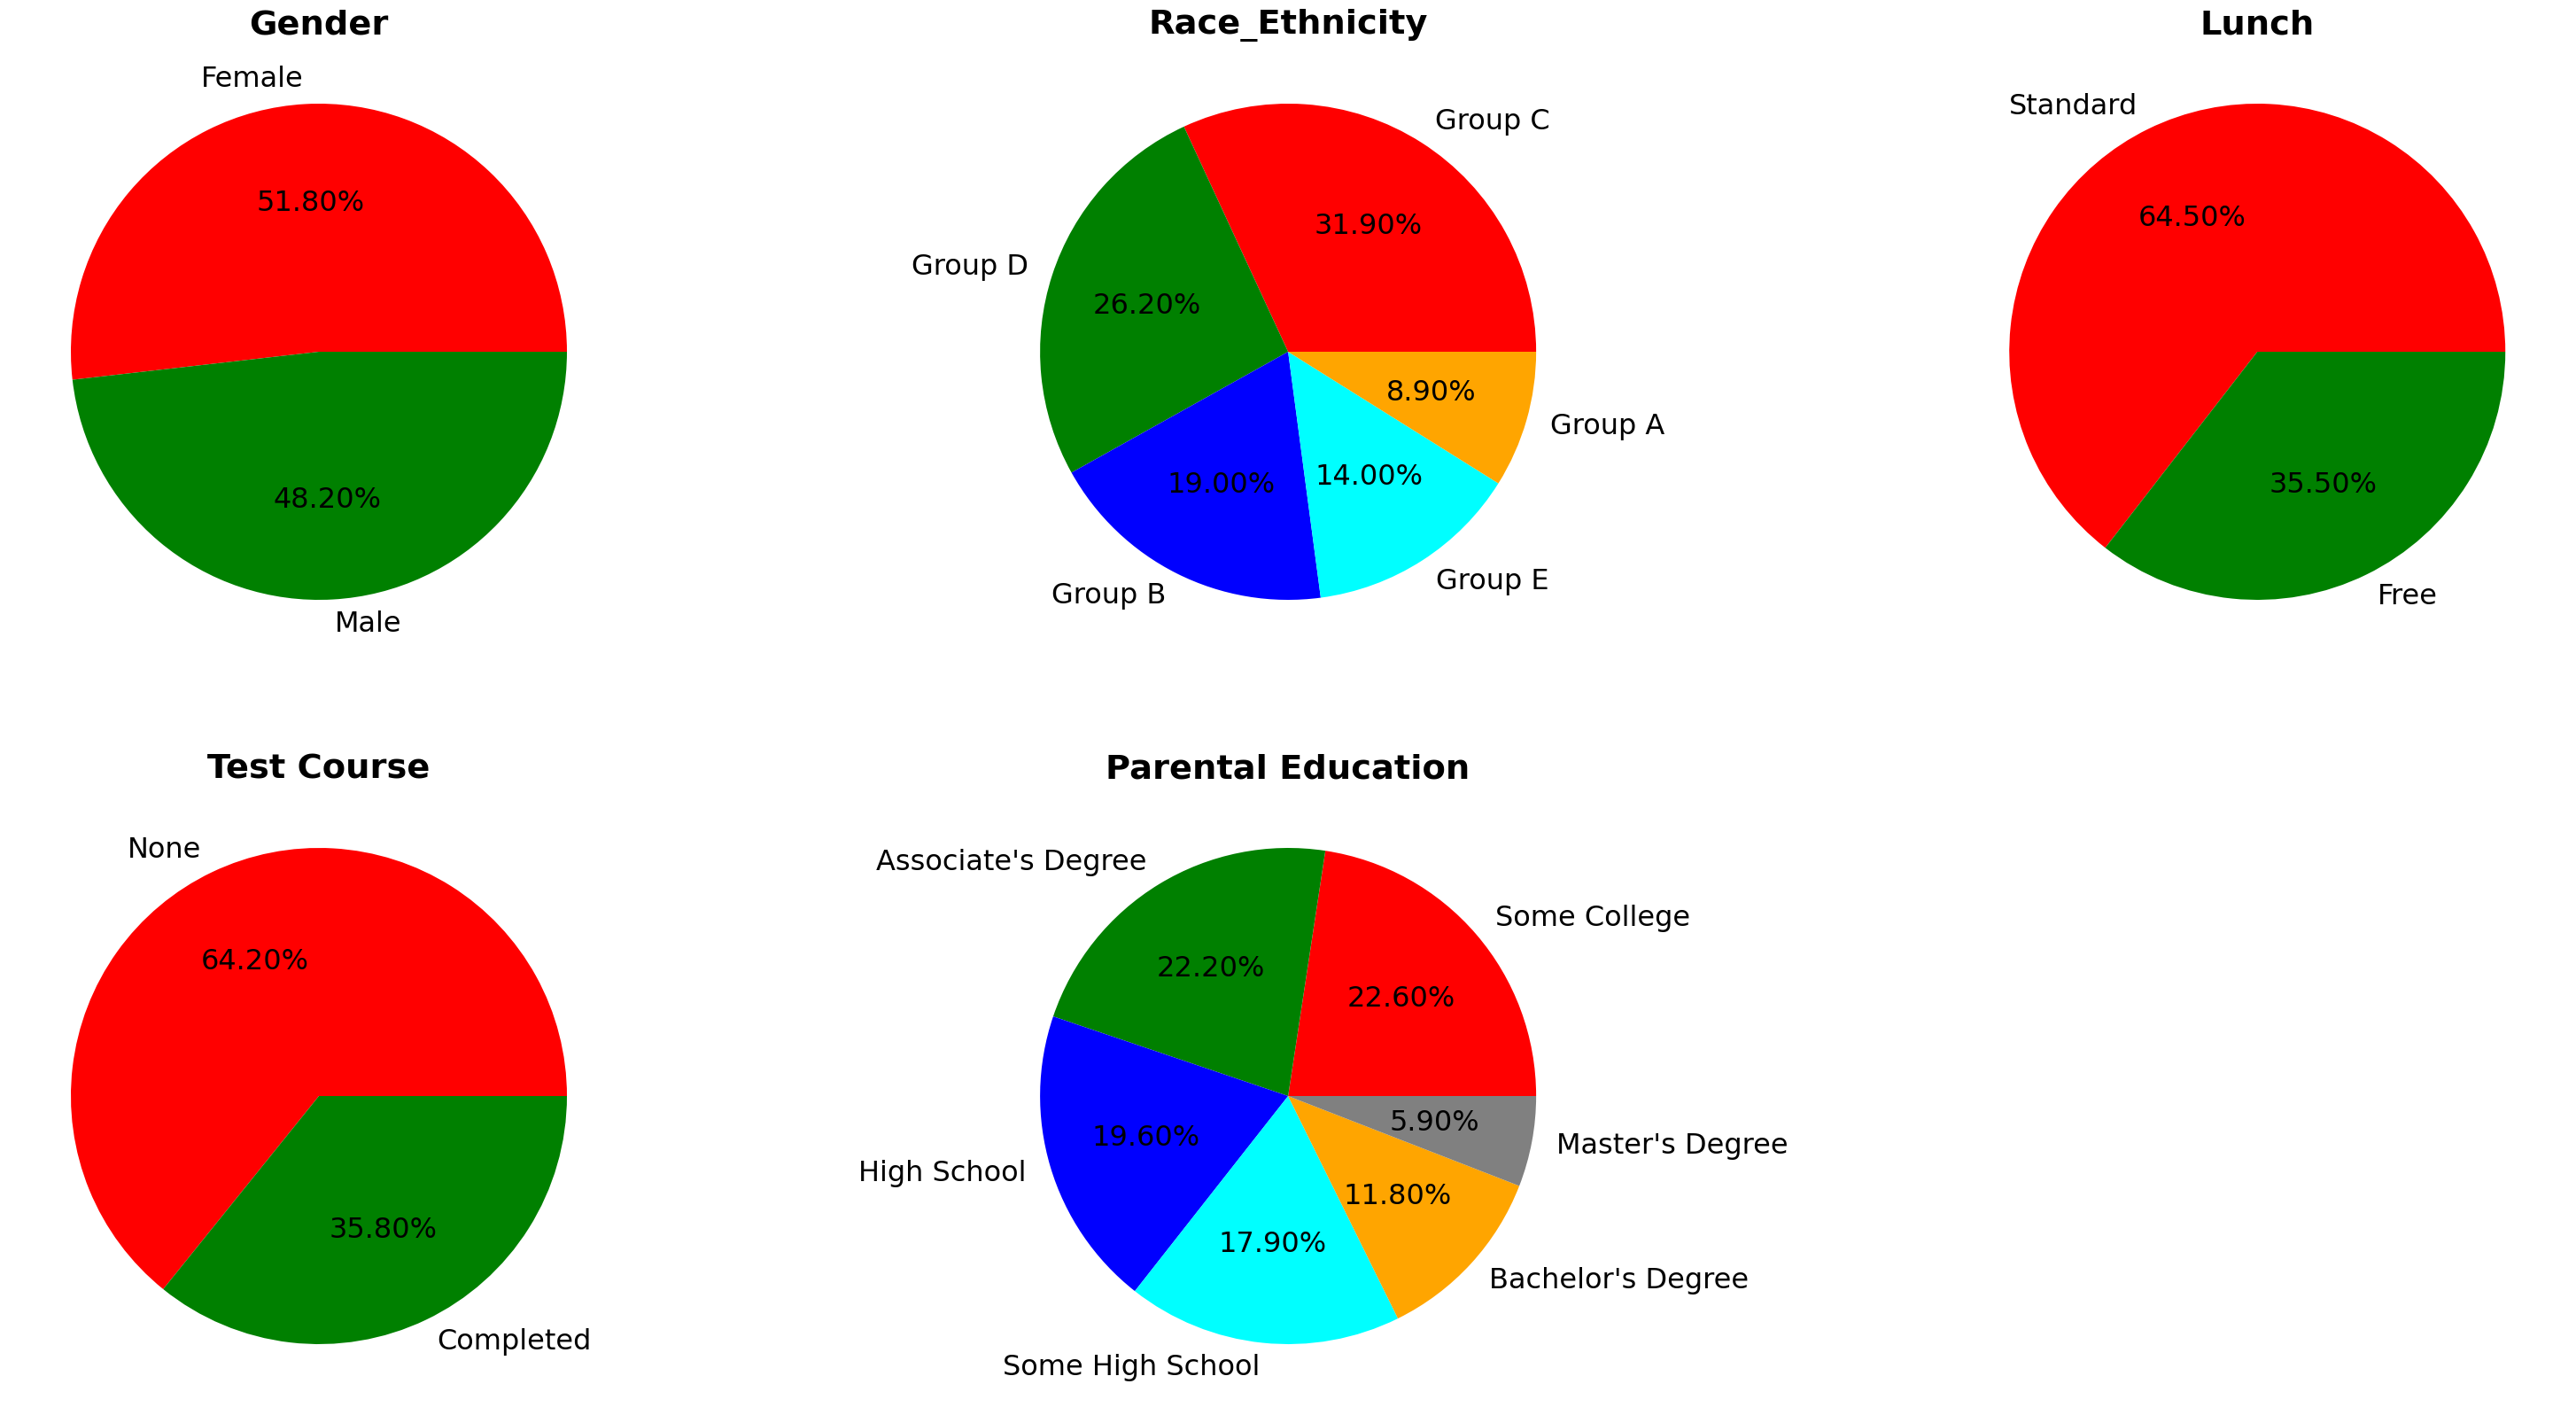

In [20]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (40, 20)
plt.rcParams['font.size'] = 23

plt.subplot(2,3,1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
colors = ['red', 'green']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Gender', fontweight='bold')

plt.subplot(2,3,2)
size = df['race'].value_counts()
labels = ['Group C', 'Group D', 'Group B', 'Group E', 'Group A']
colors = ['red', 'green', 'blue', 'cyan', 'orange']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Race_Ethnicity', fontweight='bold')

plt.subplot(2,3,3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
colors = ['red', 'green']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Lunch', fontweight='bold')

plt.subplot(2,3,4)
size = df['test_preparation_course'].value_counts()
labels = ['None', 'Completed']
colors = ['red', 'green']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Test Course', fontweight='bold')

plt.subplot(2,3,5)
size = df['parent_education'].value_counts()
labels = [
    'Some College', "Associate's Degree", 'High School',
    'Some High School', "Bachelor's Degree", "Master's Degree"
]
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Parental Education', fontweight='bold')

plt.show()

In [ ]:
Boxplots comparing Male and Female scores

What this cell does:

This cell compares male and female students’ scores.

It creates three boxplots in one row.

Each boxplot represents one subject.

The first boxplot compares Math scores by gender.

The second boxplot compares Reading scores by gender.

The third boxplot compares Writing scores by gender.

Boxplots show the median, spread, and outliers.

This helps us see which gender performs better or has more variation.

A main title is added to explain the comparison clearly.

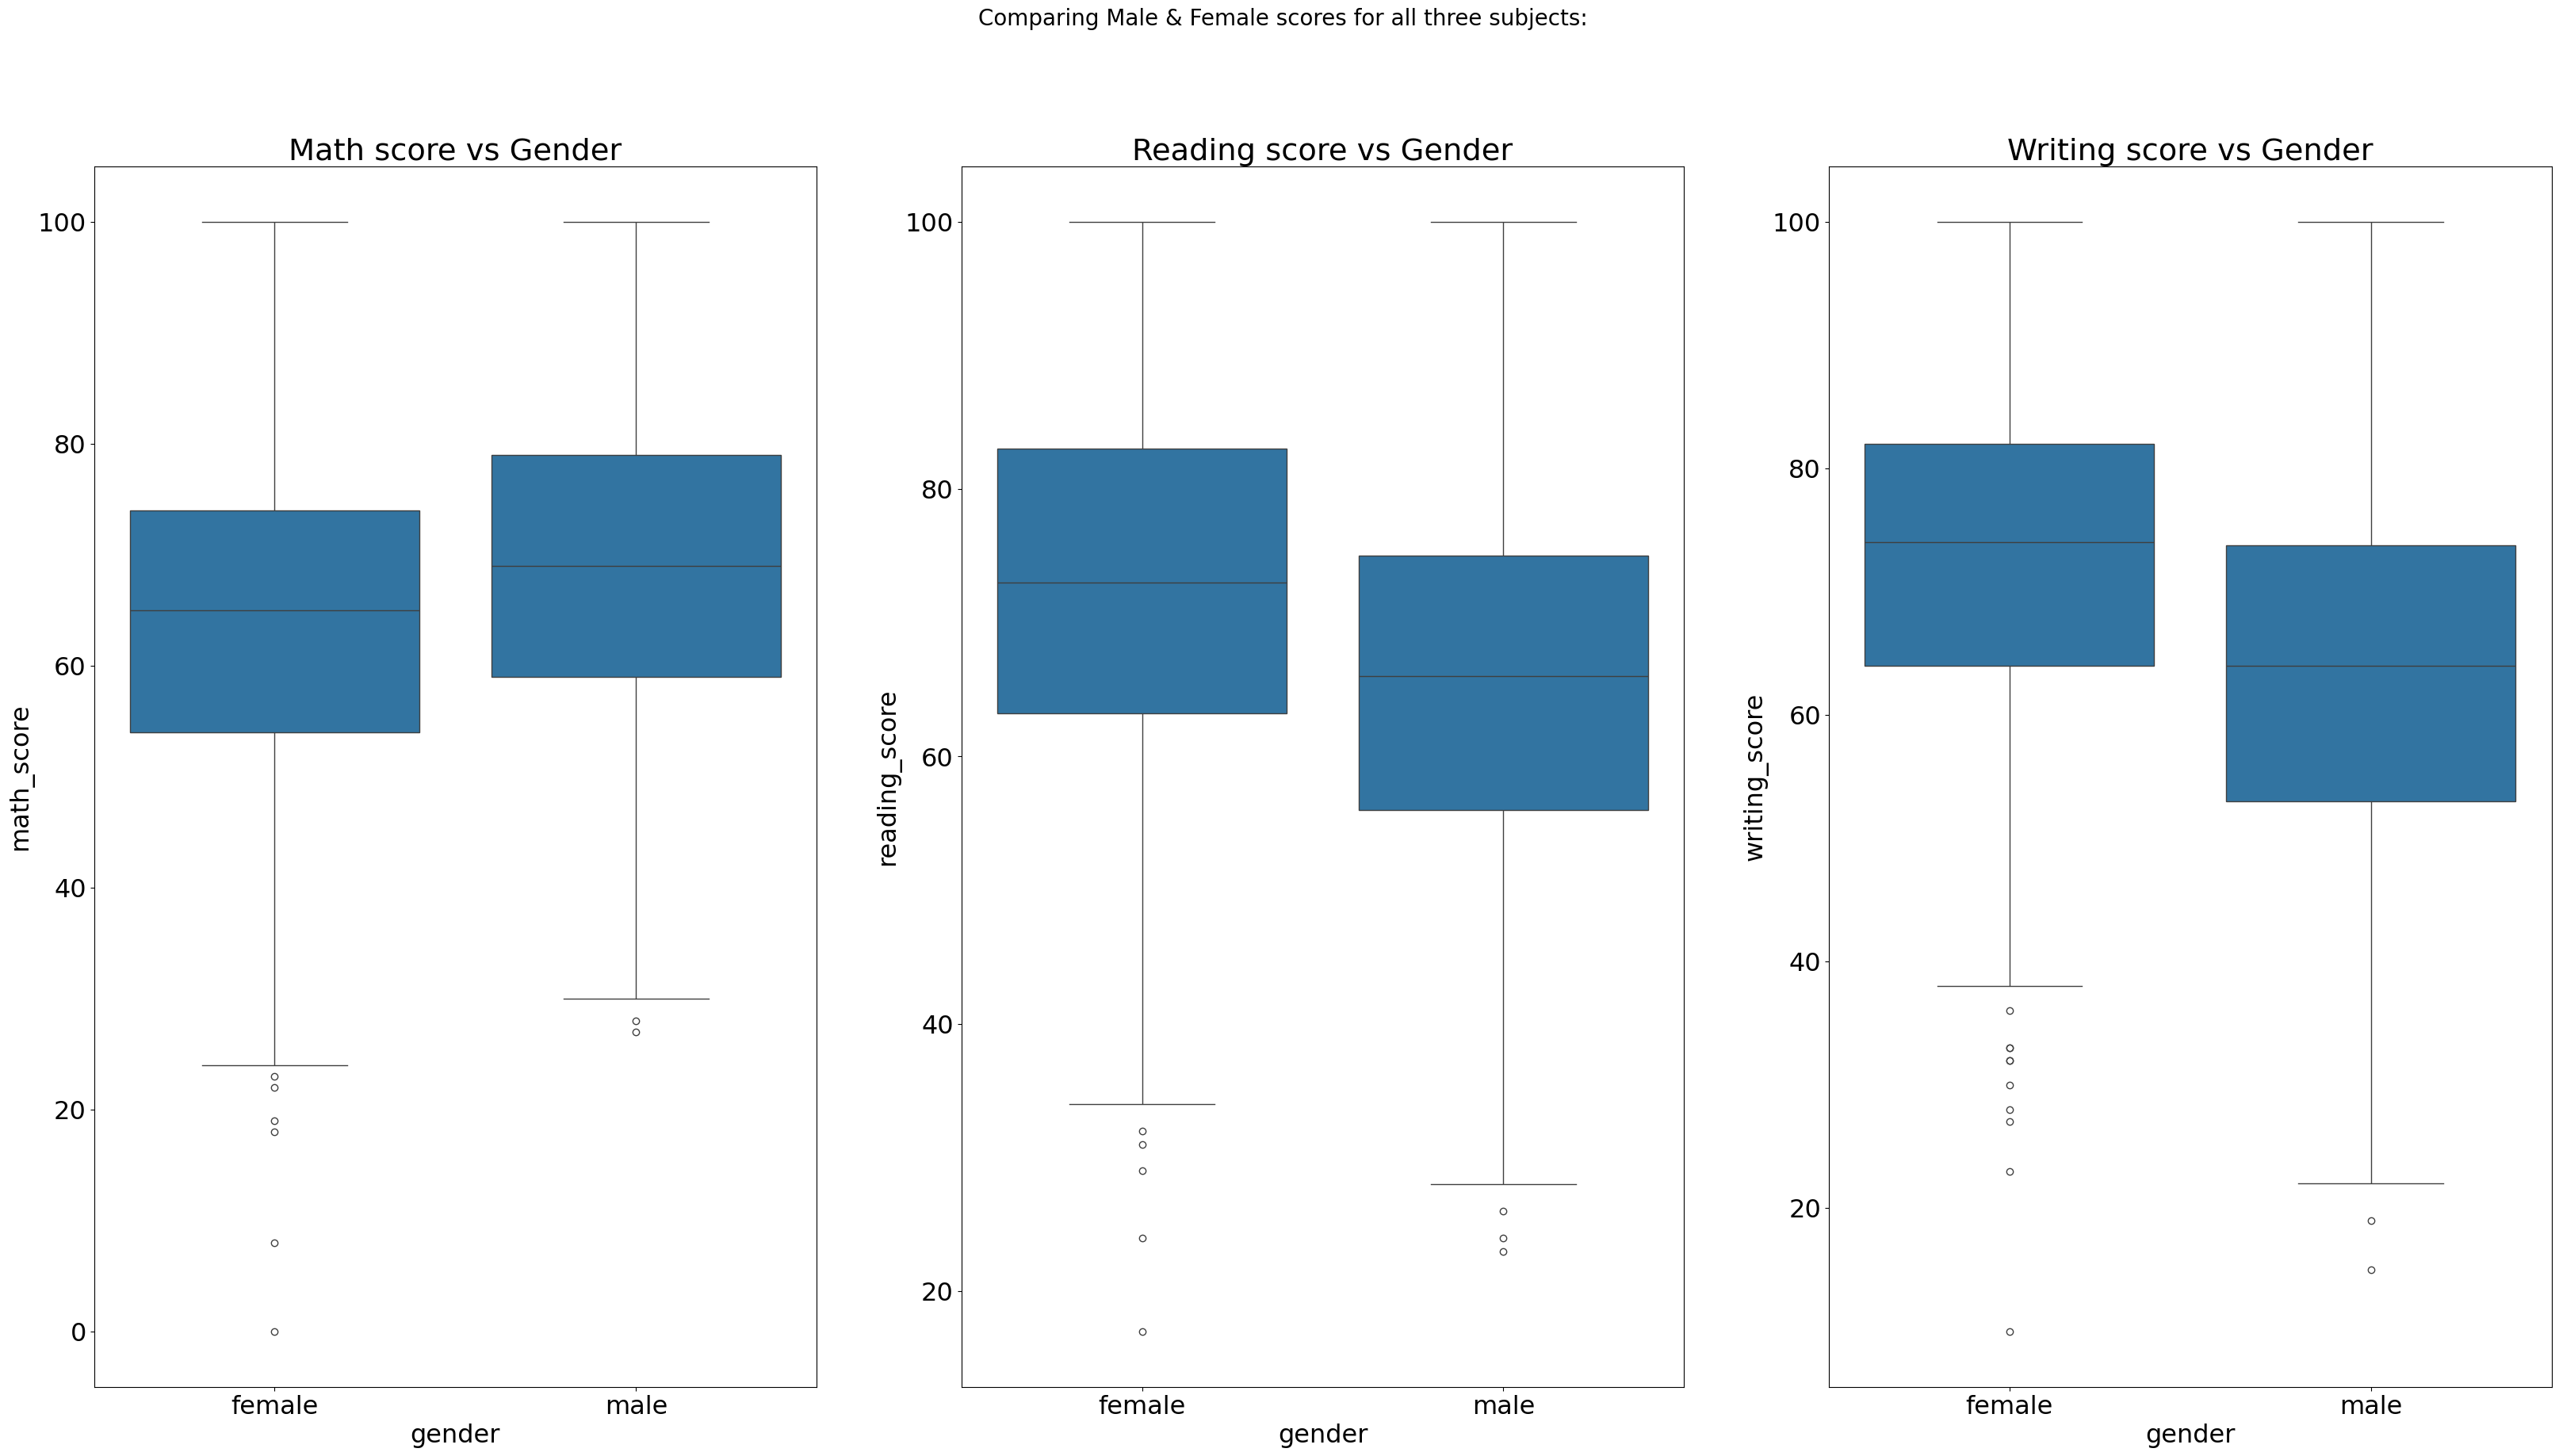

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.suptitle('Comparing Male & Female scores for all three subjects:', fontsize=20)
# Math score
sns.boxplot(x='gender', y='math_score', data=df, ax=ax1)
ax1.title.set_text('Math score vs Gender')
# Reading Score
sns.boxplot(x='gender', y='reading_score', data=df, ax=ax2)
ax2.title.set_text('Reading score vs Gender')
# Writing Score
sns.boxplot(x='gender', y='writing_score', data=df, ax=ax3)
ax3.title.set_text('Writing score vs Gender')

Boxplots comparing parents’ education and scores

What this cell does:

This cell checks if parents’ education level affects student scores.

It creates three boxplots, one for each subject.

The x-axis shows different parents’ education levels.

The y-axis shows students’ scores.

The x-axis labels are rotated so long text does not overlap.

This visualization helps us see trends between education level and performance.

We can compare medians and score spread for each education category.

/tmp/ipython-input-1509127034.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  var1 = ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)
/tmp/ipython-input-1509127034.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  var2 = ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)
/tmp/ipython-input-1509127034.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  var3 = ax3.set_xticklabels(ax3.get_xticklabels(), rotation= 30)


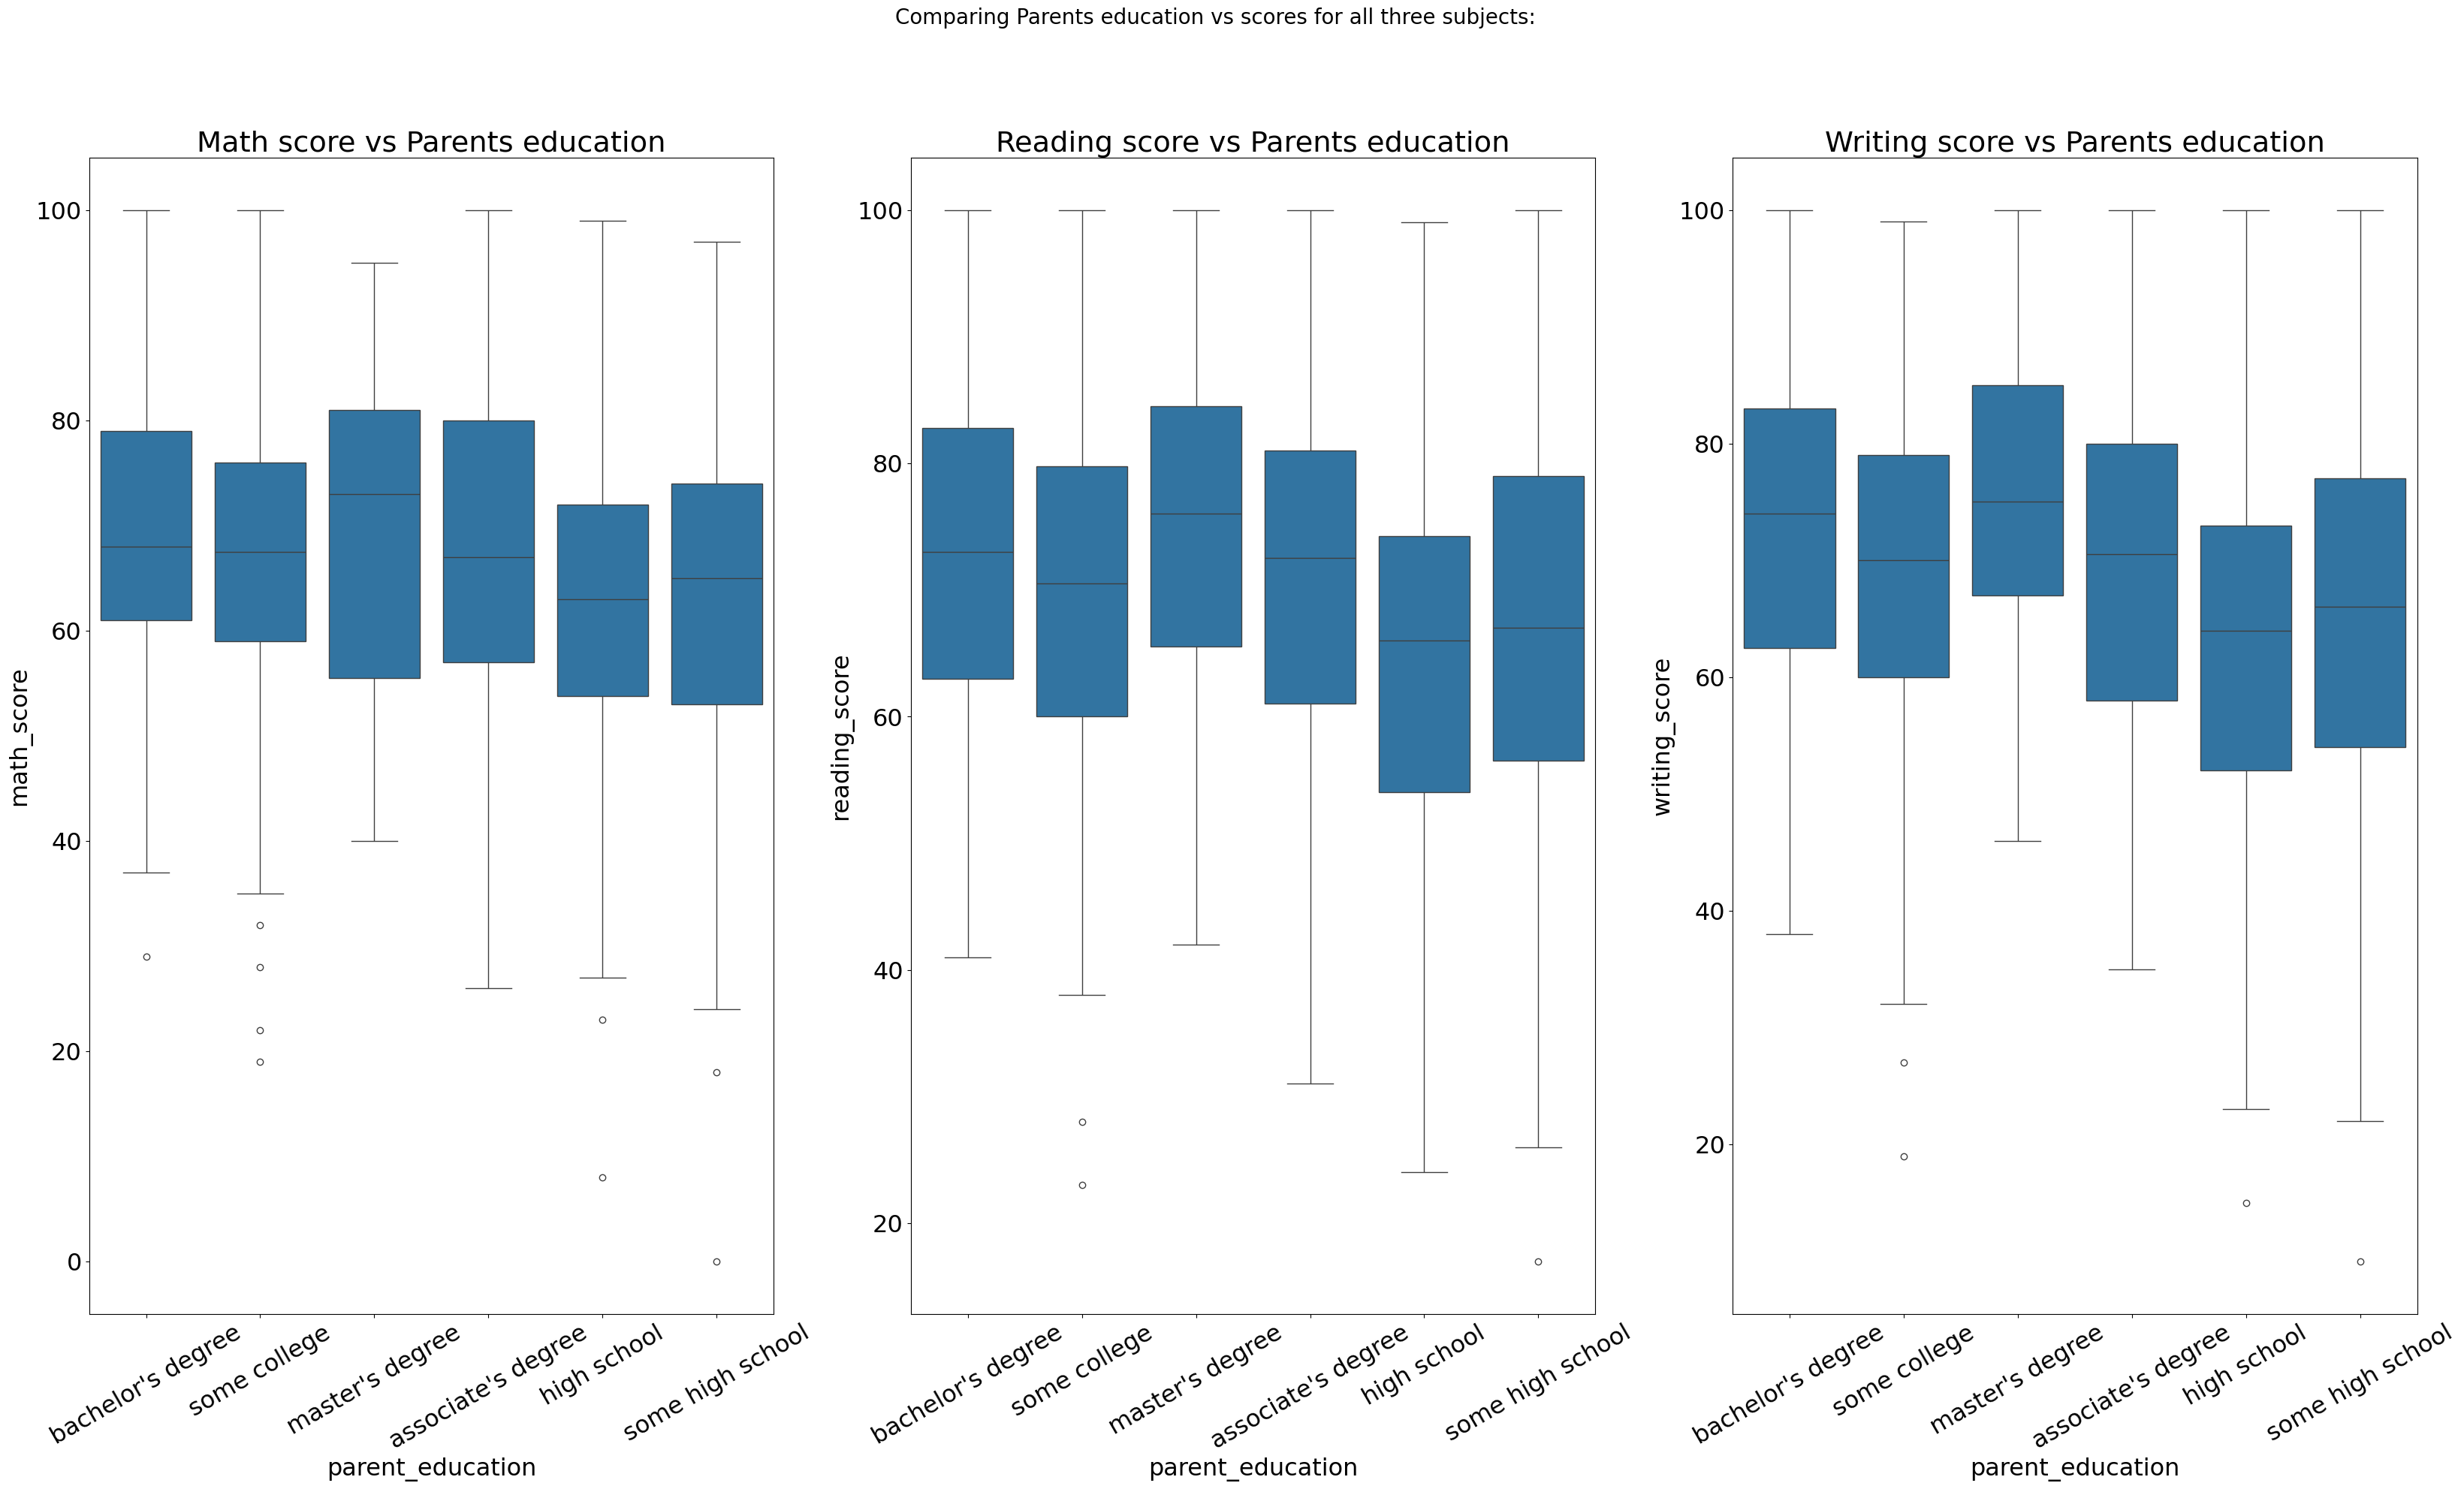

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.suptitle('Comparing Parents education vs scores for all three subjects:', fontsize=20)

# Math
sns.boxplot(x='parent_education', y='math_score', data=df, ax=ax1)
ax1.title.set_text('Math score vs Parents education')
var1 = ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30)

# Reading
sns.boxplot(x='parent_education', y='reading_score', data=df, ax=ax2)
ax2.title.set_text('Reading score vs Parents education')
var2 = ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)

# Writing
sns.boxplot(x='parent_education', y='writing_score', data=df, ax=ax3)
ax3.title.set_text('Writing score vs Parents education')
var3 = ax3.set_xticklabels(ax3.get_xticklabels(), rotation= 30)